In [15]:
import wfdb
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
from scipy import signal as scipy_signal
from scipy.signal import butter, filtfilt, lfilter
from typing import Literal

## MIT-BIH Arrhythmia Database

### Arrhythmia Database contains 48 half-hour excerpts of two-channel ambulatory ECG recordings

In [16]:
records_folder = pathlib.Path('../data/physionet.org/files/mitdb/1.0.0')

In [17]:
class Subject:
    def __init__(self, 
                 number, 
                 age, 
                 gender, 
                 meds, 
                 signal, 
                 annotations, 
                 filter_order=2,
                 fs=360,
                ):
        self.number = number
        self.age = age
        self.gender = gender
        self.meds = meds
        self.annotations = annotations        
        self.raw_signal = signal
        self.fs = fs

        self.filtered_signal, self.derivated_signal, self.squared_signal, self.integrated_signal = self.get_pt_signals(signal, filter_order, fs)
        # self.r_peak_integrated_windows = self.get_integrated_r_peaks_windows(window_span_ms=400)
    
    def z_score(self, signal):
        media = np.mean(signal)
        desvio_padrao = np.std(signal)

        if desvio_padrao == 0:
            return (signal - media)
        
        return (signal - media) / desvio_padrao

    def minmax(self, sinal_janela):
        s_min = np.min(sinal_janela)
        s_max = np.max(sinal_janela)

        if s_max == s_min:
            return np.zeros_like(sinal_janela)
    
        return (sinal_janela - s_min) / (s_max - s_min)
    
    def butterworth_filter(self, signal, order, fs=360):
        nyquist = fs/2
        low_cut = 5#hz
        high_cut = 15#hz
        low, high = low_cut / nyquist, high_cut / nyquist

        b, a = butter(order, [low, high], btype='band')

        return lfilter(b, a, signal)
    
    def causal_derivative(self, filtered_signal, fs):
        T = 1 / fs
        y = np.zeros_like(filtered_signal)

        for n in range(4, len(filtered_signal)):
            y[n] = (filtered_signal[n] + 2*filtered_signal[n-1] - 2*filtered_signal[n-3] - filtered_signal[n-4]) / (8 * T)

        return y
    
    def square_signal(self, filtered_signal):
        return np.square(filtered_signal)
    
    def moving_window_integration(self, squared_signal, fs):
        window_width = int(0.150 * fs)

        kernel = np.ones(window_width) / window_width

        integrated_signal = np.convolve(squared_signal, kernel, mode='same')

        return integrated_signal
    
    def preprocess_signal(self, raw_signal, order=2, fs=360, normalization_type='z_score'):

        filtered_signal = self.butterworth_filter(raw_signal, order, fs)
        if normalization_type == 'z_score':
            normalized_signal = self.z_score(filtered_signal)

        if normalization_type == 'min_max':
            normalized_signal = self.minmax(filtered_signal)
        return normalized_signal
    
    def pan_tompkins_preprocess(self, raw_signal, order=2, fs=360):
        filtered_signal = self.butterworth_filter(raw_signal, order, fs)
        derivated_signal = self.causal_derivative(filtered_signal, fs)
        squared_signal = self.square_signal(derivated_signal)
        integrated_signal = self.moving_window_integration(squared_signal, fs)

        return filtered_signal, derivated_signal, squared_signal, integrated_signal
    
    def get_pt_signals(self, raw_signal, order=2, fs=360):
        ch1_filtered_signal, ch1_derivated_signal, ch1_squared_signal, ch1_integrated_signal = self.pan_tompkins_preprocess(raw_signal[:,0], order=order, fs=fs)
        ch2_filtered_signal, ch2_derivated_signal, ch2_squared_signal, ch2_integrated_signal = self.pan_tompkins_preprocess(raw_signal[:,1], order=order, fs=fs)

        filtered_signal = np.column_stack((ch1_filtered_signal, ch2_filtered_signal))
        derivated_signal = np.column_stack((ch1_derivated_signal, ch2_derivated_signal))
        squared_signal = np.column_stack((ch1_squared_signal, ch2_squared_signal))
        integrated_signal = np.column_stack((ch1_integrated_signal, ch2_integrated_signal))

        return filtered_signal, derivated_signal, squared_signal, integrated_signal

    
    def plot_pt_steps(self, raw_signal, filtered_signal, derivated_signal, squared_signal, integrated_signal, fs=360, time=5):

        num_samples = time*fs
        time = np.arange(time*fs) / fs

        plt.figure(1, figsize=(10, 4))
        plt.plot(time, raw_signal[:num_samples], color='black')
        plt.title('Sinal Original')
        plt.ylabel('Amplitude')
        plt.xlabel('Tempo (s)')
        plt.tight_layout()

        plt.figure(2, figsize=(10, 4))
        plt.plot(time, filtered_signal[:num_samples], color='blue')
        plt.title('Filtro Passa-Faixa')
        plt.ylabel('Amplitude')
        plt.xlabel('Tempo (s)')
        plt.tight_layout()

        plt.figure(3, figsize=(10, 4))
        plt.plot(time, derivated_signal[:num_samples], color='green')
        plt.title('Derivação Causal')
        plt.ylabel('Amplitude')
        plt.xlabel('Tempo (s)')
        plt.tight_layout()

        plt.figure(4, figsize=(10, 4))
        plt.plot(time, squared_signal[:num_samples], color='orange')
        plt.title('Transformação Não-Linear (Quadrado)')
        plt.ylabel('Amplitude')
        plt.xlabel('Tempo (s)')
        plt.tight_layout()

        plt.figure(5, figsize=(10, 4))
        plt.plot(time, integrated_signal[:num_samples], color='red')
        plt.title('Integração por Janela Móvel')
        plt.ylabel('Amplitude')
        plt.xlabel('Tempo (s)')
        plt.tight_layout()

        plt.show()
    


        return windows_list

    def get_summary(self, channel):
        if channel == 1:
            windows = self.windows_ch1
        if channel == 2:
            windows = self.windows_ch2
        
        total = len(windows)
            
        positives = sum(w['label'] for w in windows)
        print(f"Paciente {self.number}: {total} janelas geradas.")
        print(f"Arritmias detectadas (Classe 1): {positives} | Normais (Classe 0): {total - positives}")
    
    def get_window_plot(self, channel:int, index:int, sig_size = 720):

        if channel == 1:
            window = self.windows_ch1[index]['signal']
        if channel == 2:
            window = self.windows_ch2[index]['signal']

        plt.figure(figsize=(10, 4))
        plt.plot(window[:sig_size], label=f'Channel {channel}', color='blue')

        plt.title(f"Subject channel {channel}")
        plt.xlabel("Sample #")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()

        plt.show()
    
    def get_window_label(self, channel, index):

        if channel == 1:
            window = self.windows_ch1[index]
        if channel == 2:
            window = self.windows_ch2[index]
        
        return ("Normal" if window['label'] == 0 else "Arrythimic")

    def get_window_data(self, channel, index):
        if channel == 1:
            window = self.windows_ch1[index]
        if channel == 2:
            window = self.windows_ch2[index]
        
        return window['signal']

In [18]:
def get_available_pacients(path):
    ids = set()
    for subject in os.listdir(path):
        if os.path.isfile(os.path.join(path, subject)):
            id, _ = os.path.splitext(subject)
            if len(id) == 3:
                ids.add(id)
    return sorted(ids)

### Informações dos pacientes

In [19]:
def read_subject_info(subject):
    data_path = str(records_folder/subject)
    header = wfdb.rdheader(data_path)

    comments = header.comments[0].split(' ')
    age = int(comments[0])
    gender = comments[1]

    medicine = header.comments[1]

    return [subject, age, gender, medicine]

In [20]:
data = []
for pacient in get_available_pacients(records_folder):
    subject_data = read_subject_info(pacient)
    data.append(subject_data)

df = pd.DataFrame(data, columns=['ID', 'Idade', 'Gênero', 'Medicamentos'])
df.head()


,ID,Idade,Gênero,Medicamentos
0,100,69,M,"Aldomet, Inderal"
1,101,75,F,Diapres
2,102,84,F,Digoxin
3,103,-1,M,"Diapres, Xyloprim"
4,104,66,F,"Digoxin, Pronestyl"


### Leitura dos dados

In [21]:
def read_subject_signal(subject):
    data_path = str(records_folder/subject)
    record = wfdb.rdrecord(data_path)

    signal = record.p_signal
    fs = record.fs
    sig_name = record.sig_name

    return signal, fs, sig_name

In [22]:
def read_subject_annotation(subject):
    data_path = str(records_folder/subject)
    annotation =  wfdb.rdann(data_path, 'atr')

    return annotation

In [23]:
def read_subject_data(subject, verbose=False):
    
    signal, fs, sig_name = read_subject_signal(subject)
    annotation = read_subject_annotation(subject)
    if verbose:
        print(sig_name)
        print('Signal shape:', signal.shape)
        print('Signal frequency: ', fs)
        print('number of annotated beats: ', len(annotation.sample))

    return signal, fs, annotation

##### Data sample

In [24]:
available_pacients = get_available_pacients(records_folder)

subject = available_pacients[2]
filtered_signal, fs, annotation = read_subject_data(subject, verbose=True)

signal_channel_1 = filtered_signal[:, 0]
signal_channel_2 = filtered_signal[:, 1]

['V5', 'V2']
Signal shape: (650000, 2)
Signal frequency:  360
number of annotated beats:  2192


In [25]:
print(annotation.sample[:10])
print(annotation.symbol[:10])

print(set(annotation.symbol))

[  68  136  410  697  989 1305 1614 1911 2201 2489]
['+', '/', '/', '/', '/', '/', '/', '/', '/', '/']
{'+', 'N', 'f', 'V', '/'}


###### Getting all subjects data

In [26]:
subjects : list[Subject] = []
for pacient in get_available_pacients(records_folder):
    subject_number, age, gender, meds = read_subject_info(pacient)
    signal, fs, notation = read_subject_data(pacient)

    current_subject = Subject(subject_number, age, gender, meds, signal, notation)
    subjects.append(current_subject)
    

#### Adaptative Threshold

In [27]:
class PanTompkinsQRS:
    def __init__(self, sampling_rate=360):
        self.sampling_rate = sampling_rate
        
        # Estados do limiar para o sinal integrado
        self.signal_peak_integrated = 0.0
        self.noise_peak_integrated = 0.0
        self.threshold_integrated_1 = 0.0
        self.threshold_integrated_2 = 0.0
        
        # Estados do limiar para o sinal filtrado
        self.signal_peak_filtered = 0.0
        self.noise_peak_filtered = 0.0
        self.threshold_filtered_1 = 0.0
        self.threshold_filtered_2 = 0.0
        
        # Variáveis temporais globais
        self.rr_intervals = []
        self.last_qrs_index = 0

    def find_peaks(self, integrated_signal):
        peaks_indices = []
        tracking_peak = False
        max_val = -np.inf
        max_pos = 0
        
        noise_floor = np.mean(integrated_signal)
        
        for i in range(1, len(integrated_signal)):
            if not tracking_peak:
                if integrated_signal[i] > integrated_signal[i-1] and integrated_signal[i] > noise_floor:
                    tracking_peak = True
                    max_val = integrated_signal[i]
                    max_pos = i
            else:
                if integrated_signal[i] > max_val:
                    if (integrated_signal[i] - integrated_signal[i-1]) > (max_val * 0.01):
                        max_pos = i
                    
                    max_val = integrated_signal[i]
                    
                elif integrated_signal[i] < max_val * 0.5:
                    peaks_indices.append(max_pos)
                    tracking_peak = False
                    
        return np.array(peaks_indices)


    def update_thresholds(self, peak_value, signal_peak, noise_peak, is_qrs, is_searchback=False):
        alpha = 0.25 if is_searchback else 0.125
        
        if is_qrs:
            signal_peak = alpha * peak_value + (1 - alpha) * signal_peak
        else:
            noise_peak = 0.125 * peak_value + 0.875 * noise_peak
            
        threshold_1 = noise_peak + 0.25 * (signal_peak - noise_peak)
        threshold_2 = 0.5 * threshold_1
        
        return signal_peak, noise_peak, threshold_1, threshold_2

    def apply_pan_tompkins_thresholds(self, peaks_indices, integrated_signal, filtered_signal):
        qrs_indices = []
        
        for i, current_peak_index in enumerate(peaks_indices):
            peak_val_integrated = integrated_signal[current_peak_index]
            peak_val_filtered = filtered_signal[current_peak_index]
            
            time_since_last_qrs = (current_peak_index - self.last_qrs_index) / self.sampling_rate if self.last_qrs_index != 0 else 0
            
            if 0 < time_since_last_qrs < 0.200:
                continue
                
            rr_missed_limit = 1.66 * np.mean(self.rr_intervals) if len(self.rr_intervals) > 0 else float('inf')
            is_qrs = False
            
            if time_since_last_qrs > rr_missed_limit:
                searchback_candidates = [p for p in peaks_indices[:i] if p > self.last_qrs_index]
                
                if searchback_candidates:
                    best_searchback_peak = max(searchback_candidates, key=lambda p: integrated_signal[p])
                    searchback_val_integrated = integrated_signal[best_searchback_peak]
                    searchback_val_filtered = filtered_signal[best_searchback_peak]
                    
                    if searchback_val_integrated > self.threshold_integrated_2 and searchback_val_filtered > self.threshold_filtered_2:
                        qrs_indices.append(best_searchback_peak)
                        
                        (self.signal_peak_integrated, self.noise_peak_integrated, 
                         self.threshold_integrated_1, self.threshold_integrated_2) = self.update_thresholds(
                            searchback_val_integrated, self.signal_peak_integrated, self.noise_peak_integrated, is_qrs=True, is_searchback=True)
                            
                        (self.signal_peak_filtered, self.noise_peak_filtered, 
                         self.threshold_filtered_1, self.threshold_filtered_2) = self.update_thresholds(
                            searchback_val_filtered, self.signal_peak_filtered, self.noise_peak_filtered, is_qrs=True, is_searchback=True)
                        
                        self.last_qrs_index = best_searchback_peak
                        
                        if len(qrs_indices) > 1:
                            self.rr_intervals.append((best_searchback_peak - qrs_indices[-2]) / self.sampling_rate)
                        if len(self.rr_intervals) > 8:
                            self.rr_intervals.pop(0)
                        
                        time_since_last_qrs = (current_peak_index - self.last_qrs_index) / self.sampling_rate
            
            if peak_val_integrated > self.threshold_integrated_1 and peak_val_filtered > self.threshold_filtered_1:
                is_qrs = True
                
            (self.signal_peak_integrated, self.noise_peak_integrated, 
             self.threshold_integrated_1, self.threshold_integrated_2) = self.update_thresholds(
                peak_val_integrated, self.signal_peak_integrated, self.noise_peak_integrated, is_qrs, is_searchback=False)
                
            (self.signal_peak_filtered, self.noise_peak_filtered, 
             self.threshold_filtered_1, self.threshold_filtered_2) = self.update_thresholds(
                peak_val_filtered, self.signal_peak_filtered, self.noise_peak_filtered, is_qrs, is_searchback=False)
            
            if is_qrs:
                qrs_indices.append(current_peak_index)
                if self.last_qrs_index != 0:
                    self.rr_intervals.append(time_since_last_qrs)
                    if len(self.rr_intervals) > 8:
                        self.rr_intervals.pop(0)
                self.last_qrs_index = current_peak_index
                
        return np.sort(np.unique(qrs_indices))

In [30]:
pt_agent = PanTompkinsQRS(sampling_rate=360)
detected_indices = []

for subject in subjects:
    target_integrated_signal = subject.integrated_signal[:,0]
    target_filtered_signal = subject.filtered_signal[:,0]

    candidate_indices = pt_agent.find_peaks(target_integrated_signal)
    qrs_finais = pt_agent.apply_pan_tompkins_thresholds(
    peaks_indices=candidate_indices, 
    integrated_signal=target_integrated_signal, 
    filtered_signal=target_filtered_signal)

    detected_indices.append(qrs_finais)


In [34]:
print(len(detected_indices))
print(len(detected_indices[0]))

48
2272


In [41]:
target_subject = subjects[0]
target_indices = detected_indices[0]
def plotar_marcacoes(sinal, indices):
    plt.figure(figsize=(12, 4))
    
    plt.plot(sinal, color='#1f77b4', label='Sinal original', linewidth=1)
    
    # Filtra os índices estritamente contidos nas dimensões do sinal
    indices_validos = [i for i in indices if i < len(sinal)]
    amplitudes = [sinal[i] for i in indices_validos]
    
    plt.scatter(indices_validos, amplitudes, color='red', marker='x', s=50, label='Marcações', zorder=3)
    
    plt.xlabel('Índice da Amostra')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

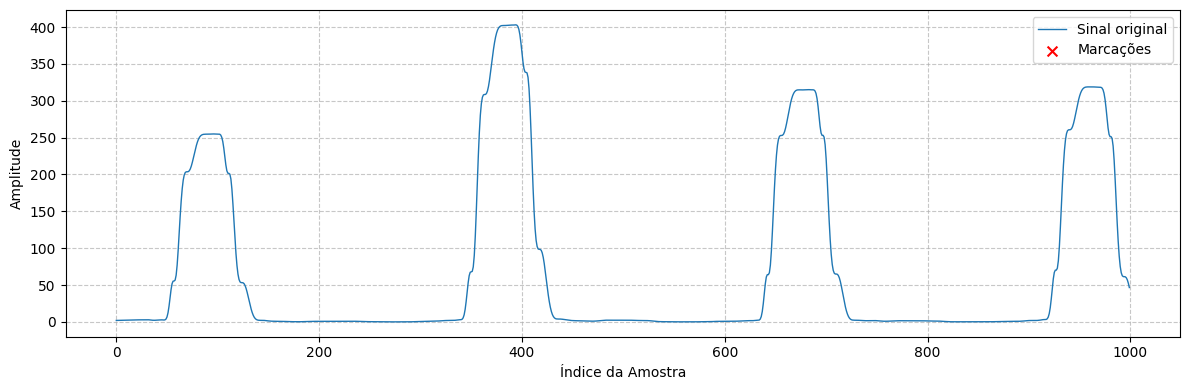

In [ ]:
plotar_marcacoes(target_subject.integrated_signal[:1000, 0], target_indices[:3])
# plotar_marcacoes(target_subject.derivated_signal[:1000, 0], qrs_finais[:3])
# plotar_marcacoes(target_subject.filtered_signal[:1000, 0], qrs_finais[:3])
# plotar_marcacoes(target_subject.raw_signal[:1000, 0], qrs_finais[:3])

##### Post-Processing

In [ ]:
def align_peaks(peak_indices, raw_signal, search_window_ms=20):
    corrected_indices = []
    signal_fs = 360#hz
    
    look_around_indices = int(search_window_ms*signal_fs/1000)

    for peak in peak_indices:
        start_index = peak-look_around_indices
        end_index = min(len(raw_signal), peak+look_around_indices)

        segment = raw_signal[start_index:end_index]

        if len(segment) > 0:
            local_max_index = np.argmax(segment)
            corrected_indices.append(local_max_index+start_index)
    
    return np.sort(corrected_indices)

In [ ]:
real_peaks = align_peaks(qrs_finais, target_subject.raw_signal[:,0], 25)
print(target_subject.annotations.sample[1:], target_subject.annotations.sample[1:].shape)
print(real_peaks, real_peaks.shape)

[    83    396    711 ... 649004 649372 649751] (1873,)
[    82    396    711 ... 649003 649371 649750] (1865,)


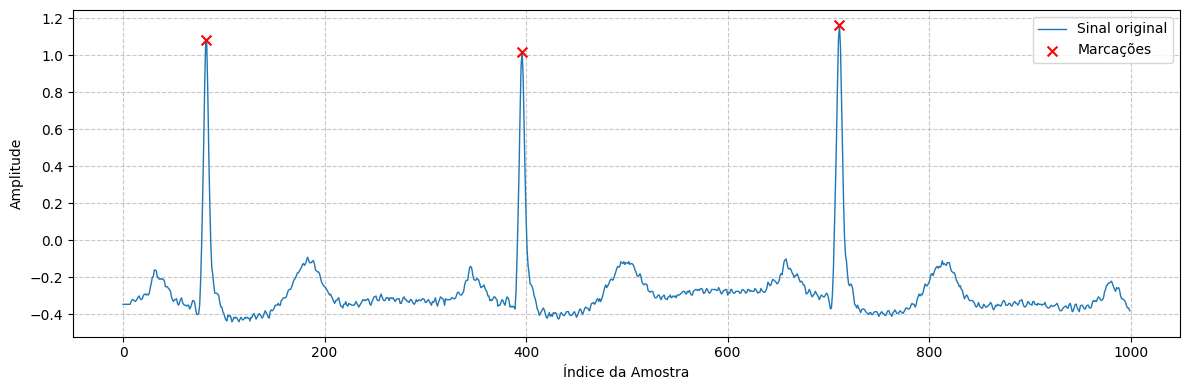

In [ ]:
plotar_marcacoes(target_subject.raw_signal[:1000, 0], real_peaks[:3])

Alguns picos naturalmente não vão ser detectados pelo algoritmo de pan-Tompkins. Por isso, é necessário fazer a distinção de quais picos foram realmente detectados e quais não foram.

Para isso colocamos um período de 150ms entre um pico real e um pico detectado. Se ele não estiver neste intervalo podemos considerá-lo um falso positivo

In [ ]:
def synchronize_peaks(annotated_peaks, labels, detected_r_peaks, detected_int_peaks, fs=360, tolerance_ms=150):
    tolerance_samples = int((tolerance_ms / 1000.0) * fs)
    
    synced_r_peaks = []
    synced_int_peaks = []
    synced_labels = []
    
    annotated_peaks = np.array(annotated_peaks)
    
    for i, det_peak in enumerate(detected_r_peaks):
        distances = np.abs(annotated_peaks - det_peak)
        
        closest_idx = np.argmin(distances)
        min_distance = distances[closest_idx]
        
        if min_distance <= tolerance_samples:
            synced_r_peaks.append(det_peak)
            synced_int_peaks.append(detected_int_peaks[i])
            synced_labels.append(labels[closest_idx])

    return synced_r_peaks, synced_int_peaks, synced_labels

In [ ]:
synced_r_peaks_indices, synced_integrated_peaks_indices, synced_labels = synchronize_peaks()

Windowing

In [ ]:
class WindowManager:
    def __init__(self, synced_filtered_peaks, synced_labels, synced_integrated_peaks, integrated_signal, filtered_signal, window_span_ms):
        self.filtered_r_peaks_windows = self.get_r_peaks_windows(self, synced_labels, synced_filtered_peaks, filtered_signal, window_span_ms)
        self.integrated_r_peaks_windows = self.get_r_peaks_windows(self, synced_labels, synced_integrated_peaks, integrated_signal, window_span_ms)

    def get_r_peaks_windows(self, synced_labels, peaks, signal, window_span_ms):
        total_window_samples = int(window_span_ms*self.fs/1000)
        half_window = total_window_samples // 2 # Sujeito a mudança
        windows_list = []
        signal = filtered_signal

        for peak, label in zip(peaks, synced_labels):
            start_idx = peak - half_window
            end_idx = peak + half_window
            if start_idx >= 0 and end_idx <= len(signal):
                window = self.filtered_signal[start_idx:end_idx]
                windows_list.append({"window": window, "label": label})

        return windows_list

Feature extraction

In [ ]:
def initialize_templates(windows_list, channel_idx=0):
    # 6 primeiras janelas
    candidates = [item["window"] for item in windows_list[:6]]
    
    if len(candidates) < 2:
        raise ValueError("Número insuficiente de candidatos (mínimo 2).")

    areas = np.array([np.sum(np.abs(cand[:, channel_idx])) for cand in candidates])
    mean_area = np.mean(areas)

    diff_to_mean = np.abs(areas - mean_area)

    group_lower_idx = np.where(areas < mean_area)[0]
    group_higher_idx = np.where(areas >= mean_area)[0]

    group_lower_idx = group_lower_idx[np.argsort(diff_to_mean[group_lower_idx])]
    group_higher_idx = group_higher_idx[np.argsort(diff_to_mean[group_higher_idx])]

    # Ranking concatenado
    ranked_indices = np.concatenate((group_lower_idx, group_higher_idx))

    templates = None
    for i in range(len(ranked_indices) - 1):
        idx1, idx2 = ranked_indices[i], ranked_indices[i+1]
        cand1 = candidates[idx1][:, channel_idx]
        cand2 = candidates[idx2][:, channel_idx]
        
        corr = np.corrcoef(cand1, cand2)[0, 1]
        
        if corr > 0.95:
            templates = [candidates[idx1], candidates[idx2]]
            break

    # Fallback: Primeiros dois candidatos do ranking
    if templates is None:
        templates = [candidates[ranked_indices[0]], candidates[ranked_indices[1]]]

    return templates

In [ ]:
def update_templates(templates, new_normal_window, channel_idx=0):
    cand_new = new_normal_window[:, channel_idx]
    
    corr0 = np.corrcoef(cand_new, templates[0][:, channel_idx])[0, 1]
    corr1 = np.corrcoef(cand_new, templates[1][:, channel_idx])[0, 1]
    
    if corr0 > corr1:
        templates[0] = new_normal_window
    else:
        templates[1] = new_normal_window
    
    return templates

### Distribuições

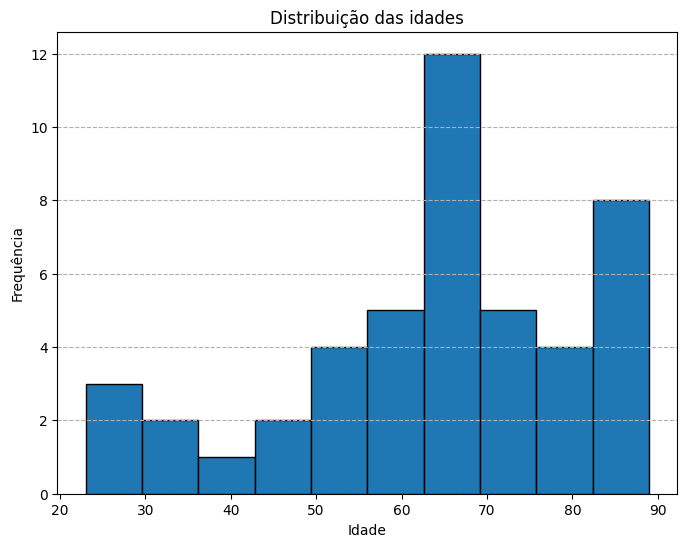

In [ ]:
valid_ages = (df['Idade'][df['Idade'] != -1])

plt.figure(figsize=(8,6))
plt.hist(valid_ages, edgecolor="black")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição das idades")
plt.grid(linestyle='--', axis='y')
plt.show()


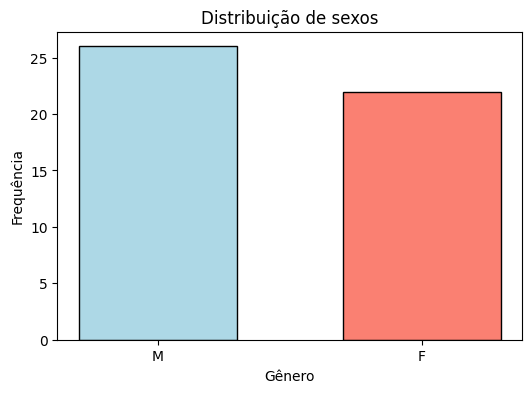

In [ ]:
gender_count = df["Gênero"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    gender_count.index,
    gender_count.values,
    edgecolor='black',
    color=['lightblue', 'salmon'],
    width=0.6)
plt.xlabel('Gênero')
plt.ylabel('Frequência')
plt.title("Distribuição de sexos")
plt.show()


In [ ]:
normal_times = []
arrythm_times = []
arrhythmia_symbols = ['L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', 'e', 'j', 'E', 'Q', '?']


for sample, symbol in zip(annotation.sample, annotation.symbol):
    time = sample/fs
    tuple_member = (time, symbol)
    if symbol in arrhythmia_symbols:
        arrythm_times.append(tuple_member)
    else:
        normal_times.append(tuple_member)

2188 4


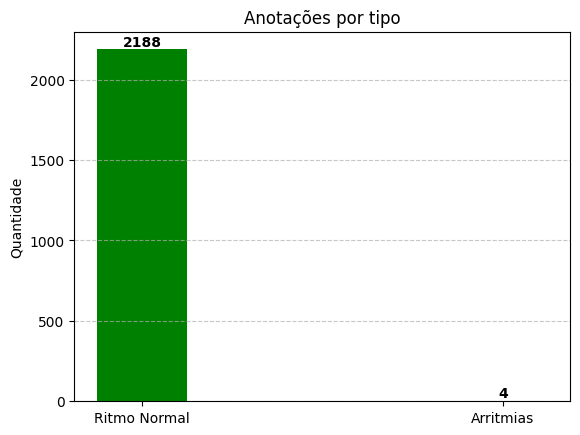

In [ ]:
normal_count = len(normal_times)
arrythm_count = len(arrythm_times)

print(normal_count, arrythm_count)



# Rótulos e valores
labels = ['Ritmo Normal', 'Arritmias']
values = [normal_count, arrythm_count]

bars = plt.bar(labels, values, color=['green', 'red'], width=0.25)

plt.xlabel('')
plt.ylabel('Quantidade')
plt.title('Anotações por tipo')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.show()

In [ ]:
normal_count/(normal_count+arrythm_count)*100

99.81751824817519

### Feature extraction

In [ ]:
def extract_average_energy(window, window_size=0):
    if window_size == 0:
        window_size = len(window['signal'])

### Subamostragem